In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms

from ilipy import Session
from ilipy.database import DistanceCorrelation
from ilipy import  Session

from rnd.utils.modeling import get_model
from rnd.utils.transform import resize_to_224
from rnd.utils.data_utils import (
    set_ili_run,
    extract_arm_angles,
    create_arm_array,
)

In [3]:
run_number = 5
root_dir = f"./data/fhr{run_number}/test_multi_class"
os.makedirs(root_dir, exist_ok=True)
_, _, inspection_id, env, _, start_dist, end_dist = set_ili_run(run_number)

session = Session(environment="research")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PySettings.cpp(46): ilipy: Build 0.17.2.10867 5d2ea142f2 release-ili-0.17 'Tue Jul 22 21:50:18 2025'
PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/defaults.json
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/research.json
PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
DatabaseWebSocket.cpp(168): WebSoc

In [4]:
class PreprocessingModel(nn.Module):
    def __init__(self, model, transform):
        super().__init__()
        self.model = model
        self.transform = transform

    def forward(self, input_np_image):
        # Apply transform to NumPy image (expects single image, not batch)
        x = self.transform(input_np_image)
        x = x.unsqueeze(0)  # Add batch dimension
        return self.model(x)

In [5]:
def load_model(model_name, dense_units, dropout, model_path):
    """
    Load a PyTorch model with weights and return it along with the transform.

    Returns:
        model (torch.nn.Module): The loaded model ready for inference.
        transform (callable): The image preprocessing pipeline.
        weights: The weight metadata used for normalization.
    """
    model, weights = get_model(model_name, dense_units, dropout)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    return model, weights

    # transform = transforms.Compose([
    #     transforms.Lambda(resize_to_224),
    #     transforms.ToTensor(),
    #     transforms.Lambda(lambda x: x.expand(3, -1, -1)),
    #     transforms.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
    # ])

    # wrapped_model = PreprocessingModel(model, transform)
    #return wrapped_model

In [6]:
model, weights = load_model("resnet", 128, 0.5, "models/dent_models/resnet_final_21_classifier_two_channels.pth")

In [7]:
transform = transforms.Compose(
    [
        transforms.Lambda(resize_to_224), # should output (C, H, W)
        transforms.Lambda(lambda x: torch.from_numpy(x).float()),
        transforms.Normalize(
            mean=weights.transforms().mean, std=weights.transforms().std
        ),
    ]
)

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: 

In [20]:
def gen_image(img_start, length= 0.3, show_im=True, normalize="range"):
    img_range = (img_start, img_start + length)
    img_center = img_start + length / 2
    tick_sampling_interval = 10

    arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
    if normalize == "range":
        arm_data_samples = extract_arm_angles(
            session=session,
            dist_corr=dist_corr,
            view_distance_range_m=(
                img_center - 10 / 2,
                img_center + 10 / 2,
            ),
            tick_sampling_interval=tick_sampling_interval,
        )
    num_tick_samples = int(length * 10000 / tick_sampling_interval)
    img = create_arm_array(
    arm_angles, arm_data_samples=arm_data_samples if normalize == "range" else None,
    num_tracks=20,
    num_tick_samples=num_tick_samples,
    normalize=normalize,
)
    if show_im: 
        plt.imshow(
            img.T, cmap="inferno", origin="lower", aspect="auto",
            interpolation="nearest",
        )
        plt.colorbar()
        plt.axis("off")
        plt.show()
    return img

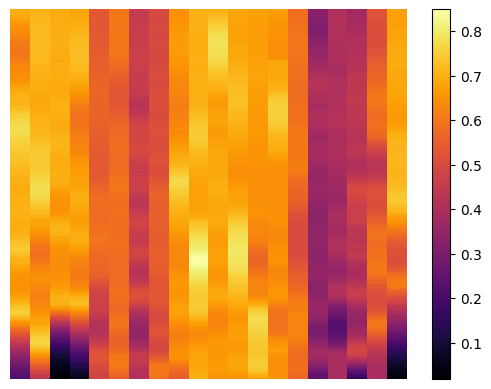

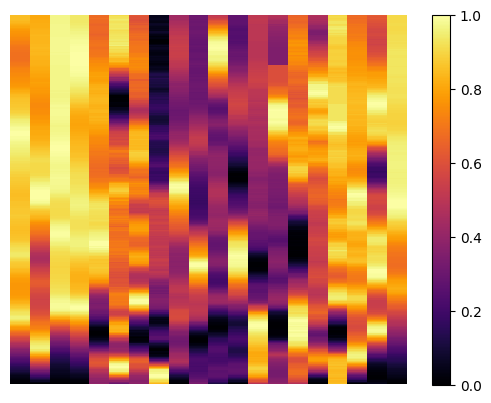

tensor(0, device='cuda:0')
0.99893767


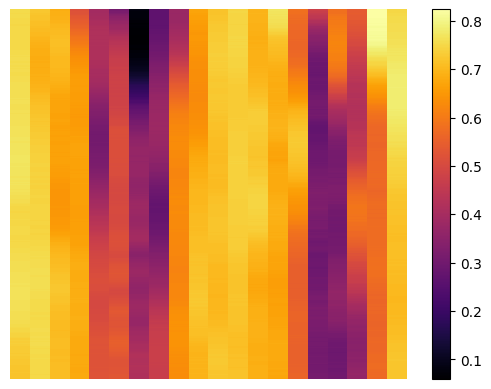

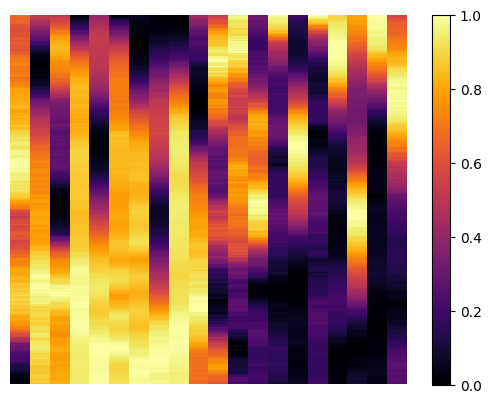

tensor(0, device='cuda:0')
0.9960223


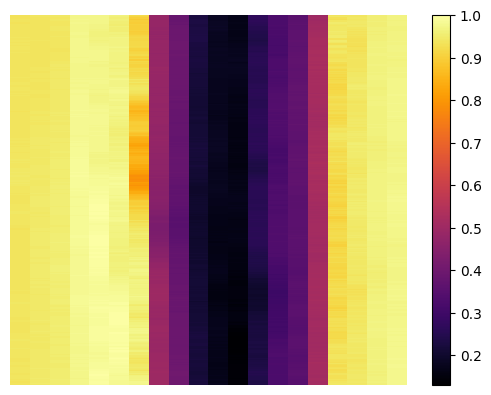

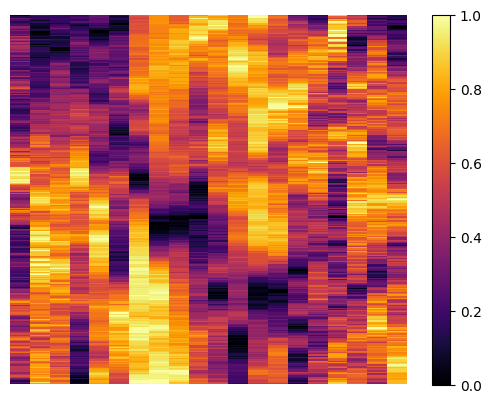

tensor(10, device='cuda:0')
0.9983071


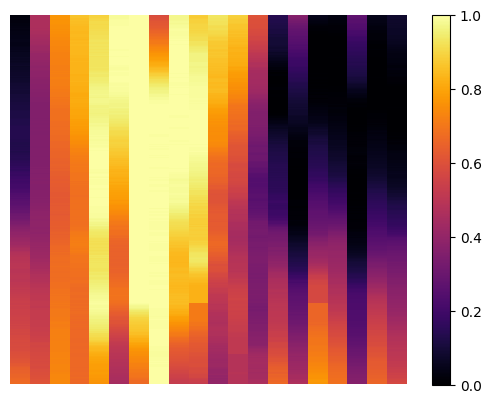

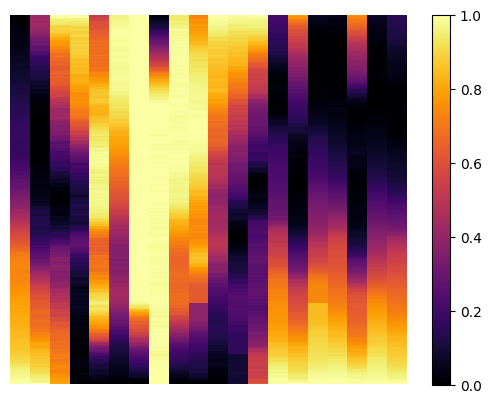

tensor(2, device='cuda:0')
0.27684748


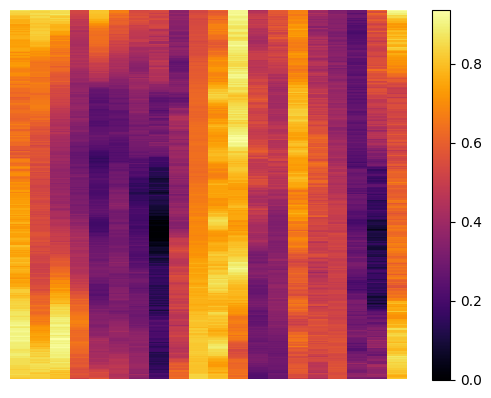

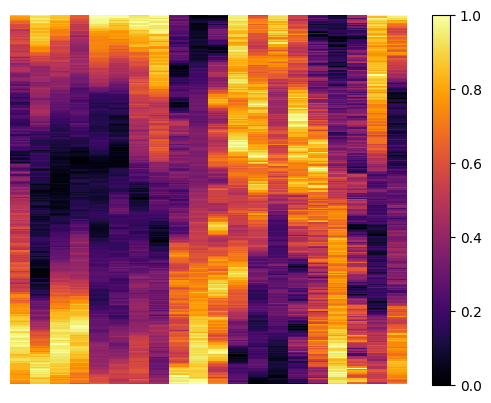

tensor(0, device='cuda:0')
0.9210171


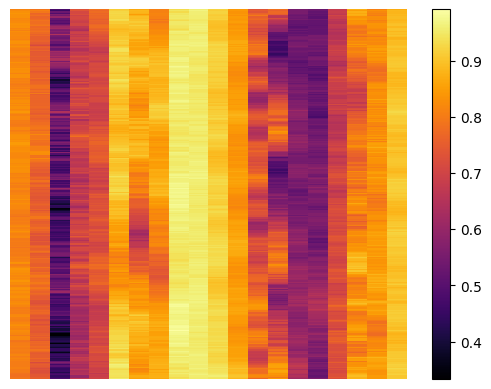

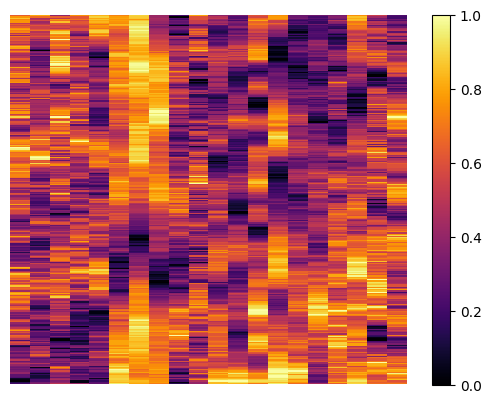

tensor(7, device='cuda:0')
0.99915075


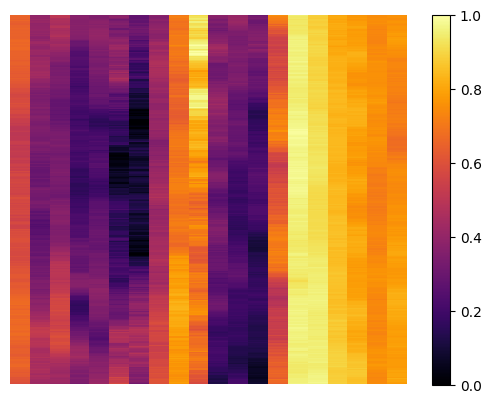

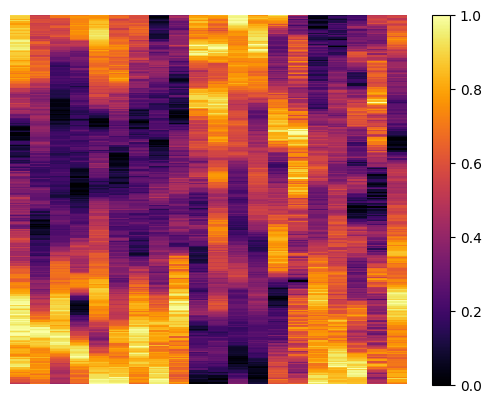

tensor(0, device='cuda:0')
0.96494186


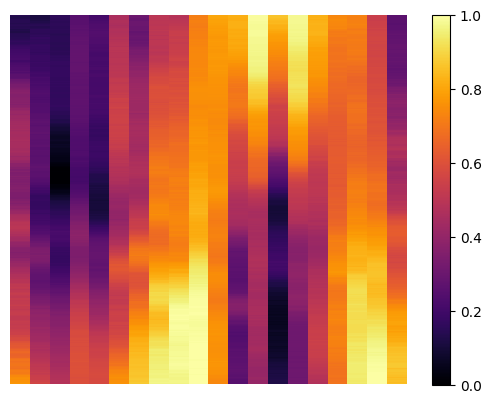

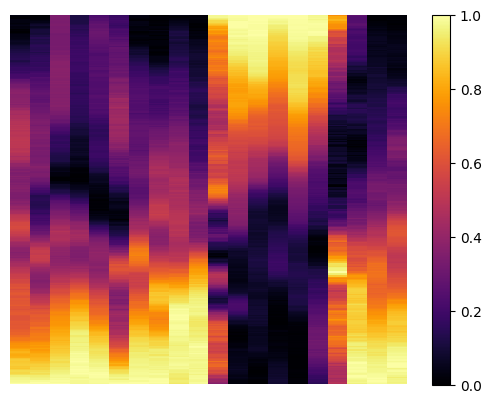

tensor(0, device='cuda:0')
0.9665943


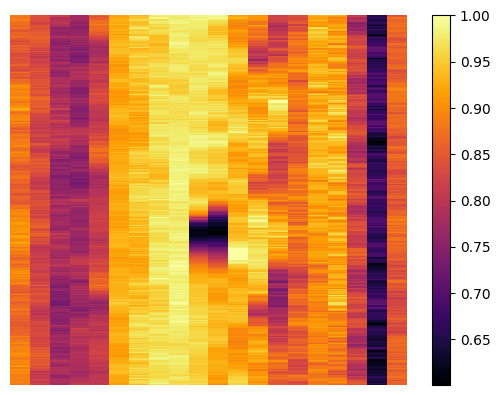

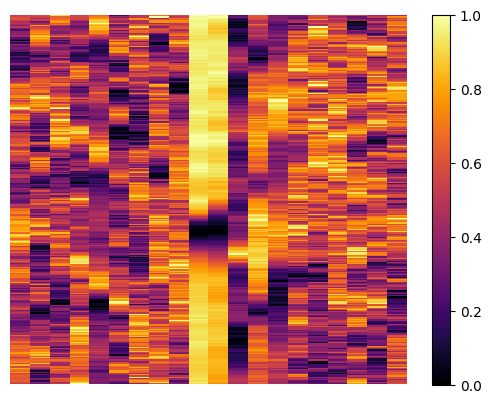

tensor(11, device='cuda:0')
0.9997414


DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.c

In [ ]:
patch_length = 0.3
model.eval()
model.to(device)
with torch.no_grad():
    for img_start in [5.37, 6.136, 15.653, 35.690,389.790, 799.641, 971.269, 1916.334, 3763.233]:
        img_range = gen_image(img_start-patch_length/2, show_im=True, normalize="range")
        img_patch = gen_image(img_start-patch_length/2, show_im=True, normalize="patch")
        img = np.stack((img_patch, img_patch, img_range), axis=0)  # shape: (3, H, W)
        img = transform(img).unsqueeze(0).to(device)
        raw_outputs = model(img)
        preds = raw_outputs.argmax()
        probs = raw_outputs.sigmoid().max().cpu().numpy()
        print(preds)
        print(probs)

